wandb:   1 of 1 files downloaded.  


Ultralytics 8.4.47  Python-3.13.13 torch-2.11.0+cpu CPU (Intel Core Ultra 7 258V)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 740.577.5 MB/s, size: 109.1 KB)
val: Scanning C:\Users\josep\Documents\ZHAW\Machine Learning Operations\Pigeon Guard\model\dataset\labels.cache... 318 images, 112 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 318/318 51.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.0it/s 5.1s0.2s
                   all        318        294      0.971      0.952      0.959       0.59
Speed: 0.1ms preprocess, 8.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\josep\Documents\ZHAW\Machine Learning Operations\Pigeon Guard\model\runs\detect\val-5


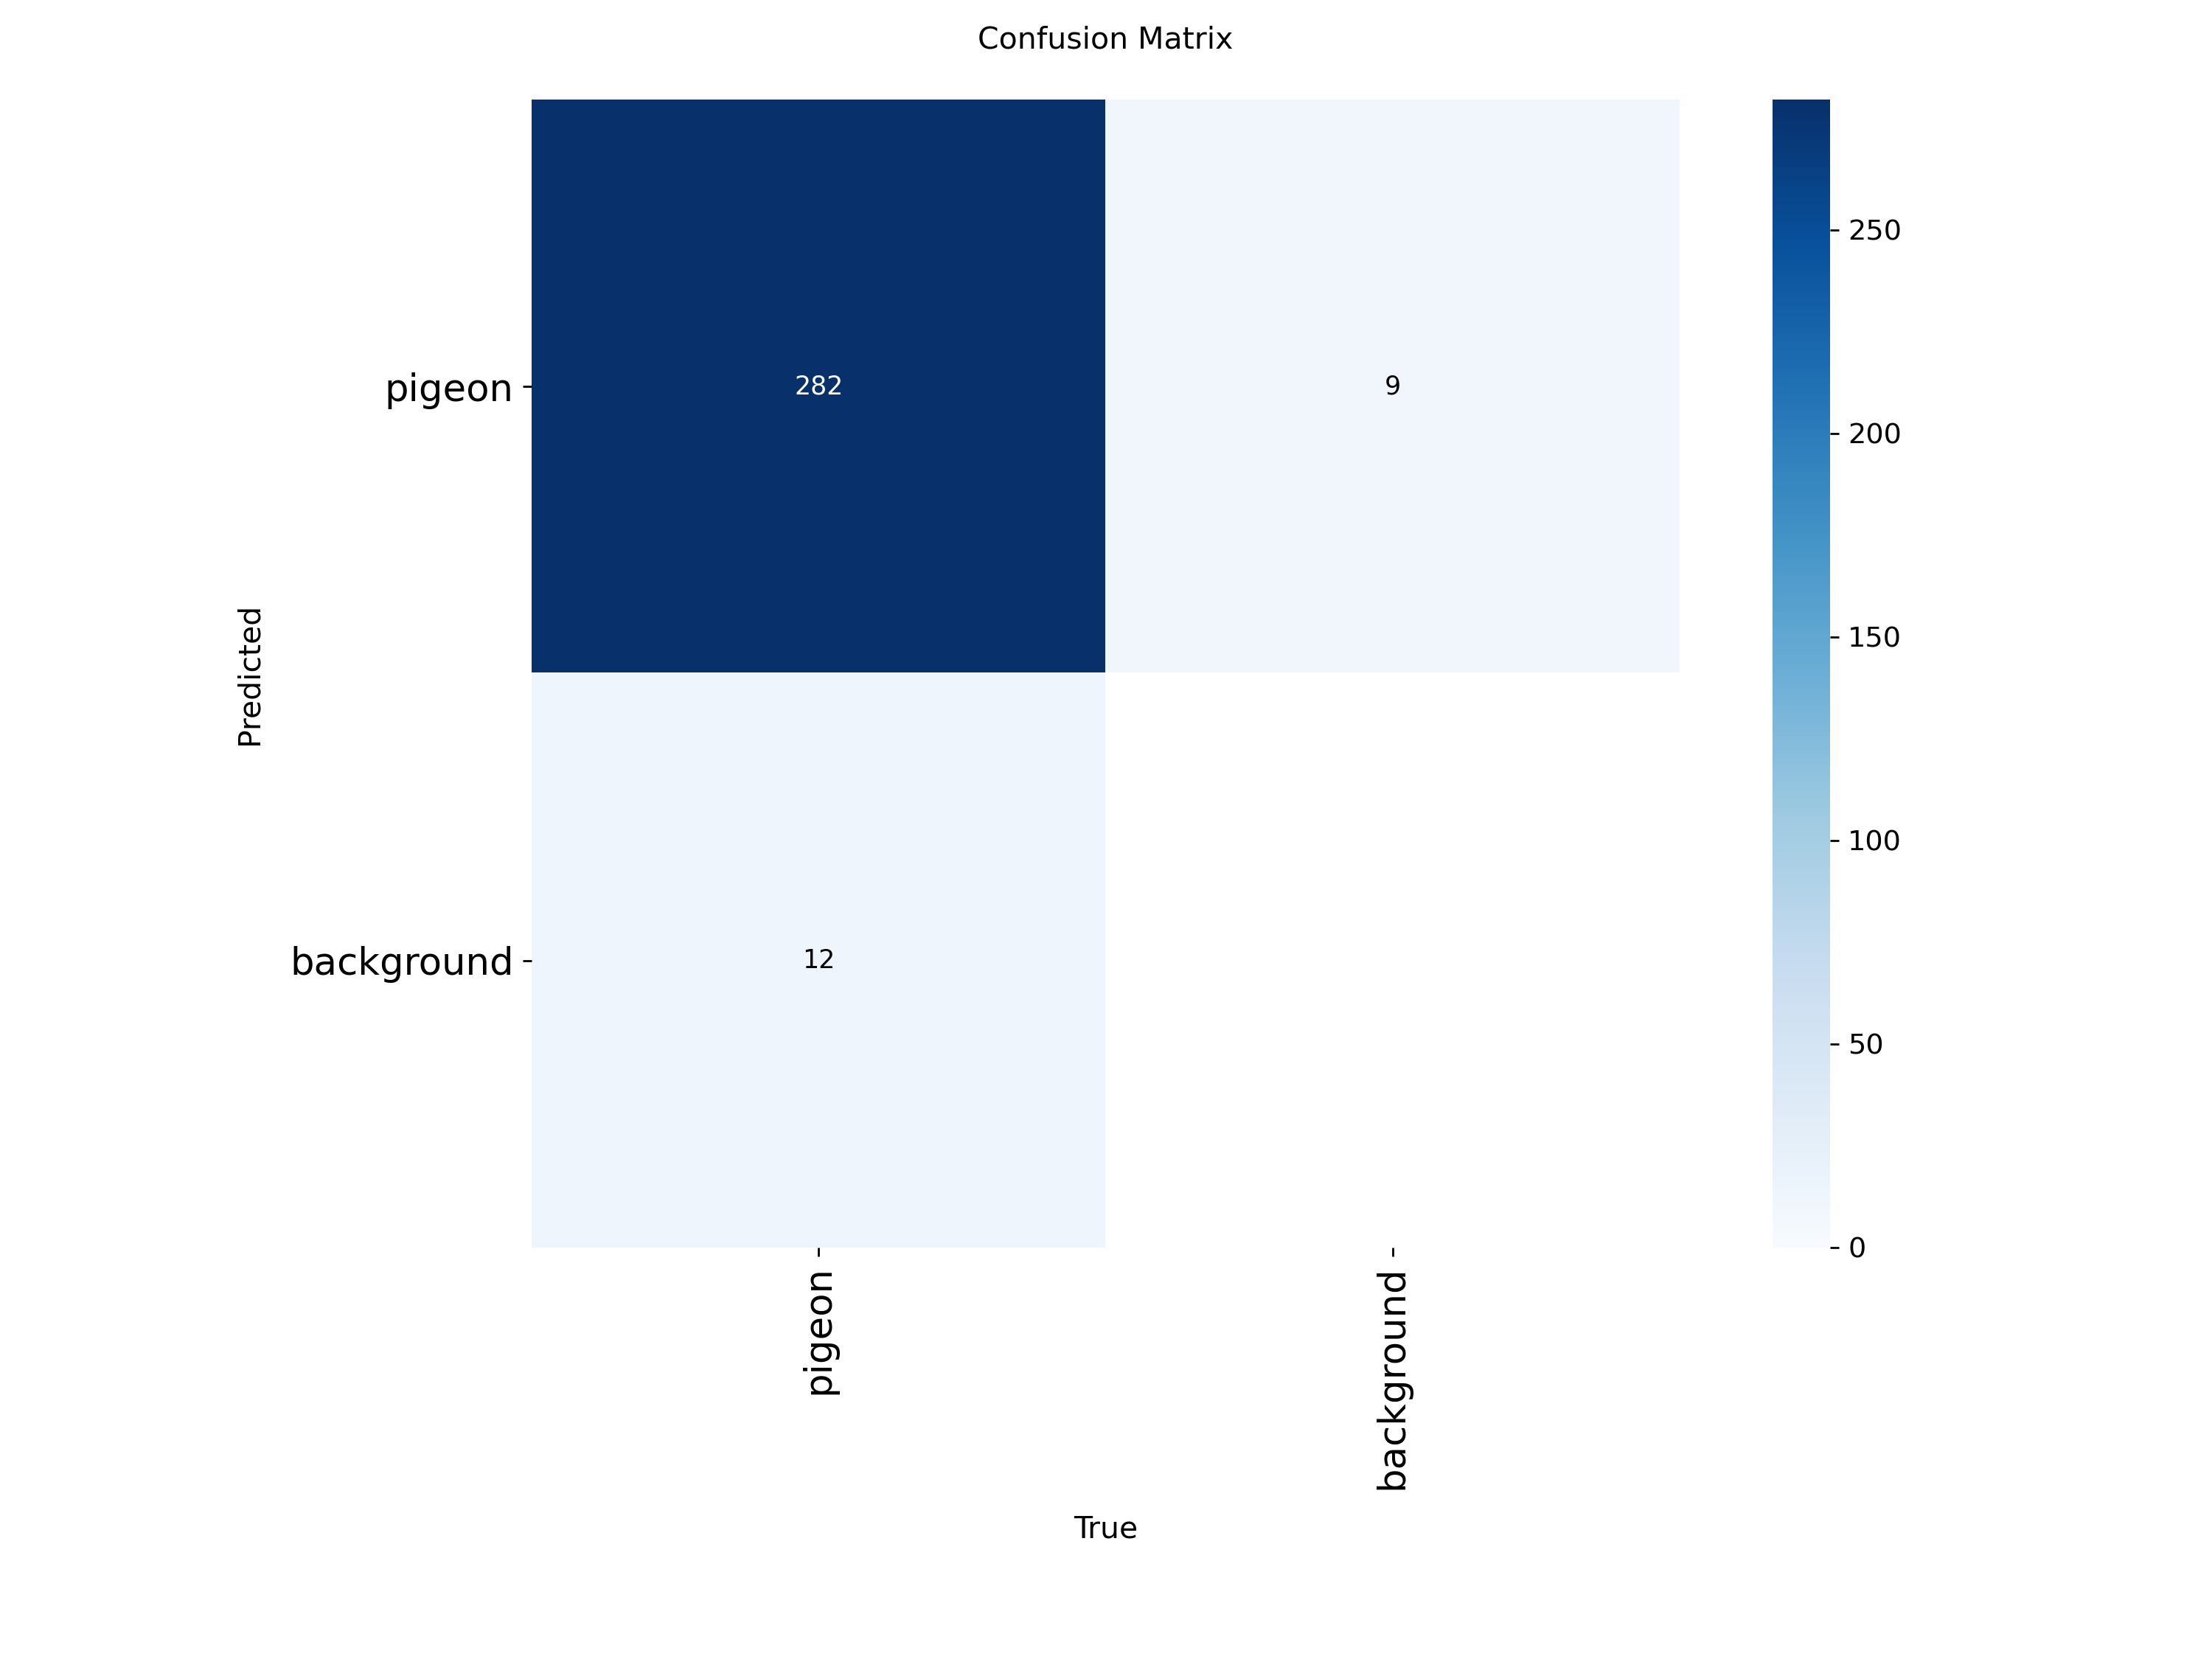

In [8]:
from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import wandb

api = wandb.Api()
artifact = api.artifact("jotamunz-org/wandb-registry-pigeon-guard/yolo-model:production")
artifact_dir = artifact.download()

pt_path = next(Path(artifact_dir).rglob("*.pt"))

data = "dataset/data.yaml"
imgsz = 224
split = "test"

model = YOLO(str(pt_path))
metrics = model.val(data=data, imgsz=imgsz, split=split, plots=True)
cm_path = Path(metrics.save_dir) / "confusion_matrix.png"
display(Image(filename=str(cm_path)))